# [Computer Vision AIG210 Project: Object Classification with Transfer Learning](https://github.com/jcp-tech/Seneca_Class_Notes/blob/master/Semester%202/AIG210%20-%20Computer%20Vision/Final%20Project/Project.ipynb)

### Overview
In this project, you will build a complete computer vision pipeline that classifies common household or outdoor objects. You will go through all stages of the ML pipeline:
1. Data collection
2. Data labeling
3. Preprocessing and augmentation
4. Training using a pre-trained model (transfer learning)
5. Evaluation
6. Visualization

The aim is to simulate a real-world scenario where labeled data is scarce, so you'll collect and label a small dataset and fine-tune a pre-trained model.

---

## 1. Project Setup
- Use Python and Jupyter Notebook.
- Recommended libraries: `torch`, `torchvision`, `opencv-python`, `matplotlib`, `scikit-learn`, `Pillow`, `numpy`. You may use `TensorFlow` instead of `PyTorch`.
- You can use Google Colab, Kaggle Kernels, or a local Jupyter environment.

In [56]:
# Core Python
import numpy as np
import seaborn as sns
from PIL import Image
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import matplotlib.pyplot as plt
import torch.nn.functional as F
import matplotlib.patches as patches
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import os, shutil, random, warnings, kagglehub, torch, torchvision
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42  # Set a seed for reproducibility

random.seed(SEED)                # Sets Python's random module seed for reproducible random operations
np.random.seed(SEED)             # Sets NumPy's random seed for consistent results in NumPy-based randomness
torch.manual_seed(SEED)          # Sets PyTorch's CPU random seed for reproducible weight initialization and shuffling
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED) # Sets PyTorch's GPU random seed for reproducibility in CUDA (GPU) computations
  print('CUDA available:', torch.cuda.is_available())
else:
  print('CUDA not available')

warnings.filterwarnings("ignore")  # Suppresses warnings to keep the output clean

CUDA available: True


In [57]:
def plot_classwise_samples(dataset_path, class_names, samples_per_class_per_row=6, num_rows=1):
    total_samples = samples_per_class_per_row * num_rows
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_path):
            os.makedirs(class_path, exist_ok=True)
        images = os.listdir(class_path)[:total_samples]

        # Figure width fixed to notebook width, height scales with rows
        fig, axs = plt.subplots(
            num_rows,
            samples_per_class_per_row,
            figsize=(18, 18 * num_rows / samples_per_class_per_row),
            dpi=100
        )
        fig.suptitle(f"Class: {class_name}", fontsize=16, y=1.02)

        axs = axs.flatten() if total_samples > 1 else [axs]

        for i, ax in enumerate(axs):
            if i < len(images):
                img_path = os.path.join(class_path, images[i])
                img = Image.open(img_path)
                ax.imshow(img)
                ax.axis('off')
            else:
                ax.axis('off')

        # 🔧 Zero spacing between images
        plt.subplots_adjust(wspace=0.01, hspace=0.01)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

def get_class_distribution(subset, class_names):
    """Counts number of images for each class in a PyTorch Subset."""
    labels = [subset.dataset.targets[i] for i in subset.indices]
    count = Counter(labels)
    return {class_names[k]: v for k, v in count.items()}


# These are standard ImageNet mean/std values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

def show_test_predictions_grid(
    all_imgs, all_preds, all_labels, all_probs, class_names,
    num_rows=4, num_cols=8, misclassified_only=None
):
    """
    - misclassified_only = True: show only misclassified images
    - misclassified_only = False: show only correctly classified images
    - misclassified_only = None: show all
    """
    if misclassified_only is True:  # Show only misclassified
        idxs = [i for i in range(len(all_labels)) if all_preds[i] != all_labels[i]]
        title = "Misclassified Images"
        if not idxs:
            print("No misclassified images!")
            return
    elif misclassified_only is False:  # Show only correct
        idxs = [i for i in range(len(all_labels)) if all_preds[i] == all_labels[i]]
        title = "Correctly Classified Images"
        if not idxs:
            print("No correctly classified images!")
            return
    else:  # None: show all
        idxs = list(range(len(all_labels)))
        title = "All Images"
        if not idxs:
            print("No images to display!")
            return

    # Select only the filtered indices
    sel_imgs = [all_imgs[i] for i in idxs]
    sel_preds = [all_preds[i] for i in idxs]
    sel_labels = [all_labels[i] for i in idxs]
    sel_probs = [all_probs[i] for i in idxs]

    max_images = num_cols * num_rows
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4.5))
    axs = axs.flatten()
    plt.subplots_adjust(wspace=0.3, hspace=0.8)

    for idx in range(min(max_images, len(sel_imgs))):
        ax = axs[idx]
        img = sel_imgs[idx].permute(1, 2, 0).numpy()
        img = img * imagenet_std + imagenet_mean  # unnormalize
        img = np.clip(img, 0, 1)
        pred_label = class_names[sel_preds[idx]]
        true_label = class_names[sel_labels[idx]]
        conf = sel_probs[idx][sel_preds[idx]]
        correct = (sel_preds[idx] == sel_labels[idx])

        # Display the image
        ax.imshow(img)
        ax.axis('off')

        # Draw black rectangle border around the image
        height, width = img.shape[:2]
        rect = patches.Rectangle(
            (0, 0), width-1, height-1,
            linewidth=3, edgecolor='black', facecolor='none'
        )
        ax.add_patch(rect)

        # Prediction box below the image, in green/red with black text border
        box_text = (
            f"Pred: {pred_label} | Conf: {conf:.2f}\n"  # Prediction and Confidence
            f"True: {true_label}"
        )
        box_color = 'green' if correct else 'red'
        # Place the text box below the image, outside the plot area using transform
        ax.text(
            0.5, -0.22, box_text,
            ha='center', va='top',
            color='white', fontsize=11, weight='bold',
            bbox=dict(boxstyle="round,pad=0.4", facecolor=box_color, edgecolor='black', alpha=0.9),
            transform=ax.transAxes,
            clip_on=False
        )
    # Hide unused subplots, if any
    for idx in range(min(max_images, len(sel_imgs)), len(axs)):
        axs[idx].axis('off')

    fig.suptitle(title, fontsize=18, y=0.92) # plt.subtitle | is Giving to much White Space.
    plt.tight_layout(rect=[0, 0, 1, 0.92])  # Reserve more top space for title
    plt.show()

def show_batch(loader, class_names):
    imgs, labels = next(iter(loader))
    grid = torchvision.utils.make_grid(imgs[:8], nrow=4, normalize=True, pad_value=1)
    plt.figure(figsize=(12,6))
    plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)))
    plt.axis('off')
    plt.title("Sample batch from DataLoader\nLabels: " + ", ".join([class_names[i] for i in labels[:8]]))
    plt.show()

def cal_col_rows(num_images, max_cols=5):
    cols = int(np.ceil(np.sqrt(num_images))) if not(int(np.ceil(np.sqrt(num_images))) > max_cols) else max_cols  # min(int(np.ceil(np.sqrt(num_images))), max_cols)
    rows = int(np.ceil(num_images / cols))
    return cols, rows

---
## 2. Data Collection

- Choose (at least) **two everyday object categories** that are easy to collect around your home or outdoors. Examples include:
  - Cups vs. bottles
  - Shoes vs. sandals
  - Forks vs. spoons
  - Apples vs. bananas

- Collect **20–30 images per class** (more is better if time allows).
- You can:
  - Take pictures using your phone (use various angles, lighting, and backgrounds)
  - Search and download from Google Images
  - Use free datasets like [Open Images](https://storage.googleapis.com/openimages/web/index.html)

👉 Tip: Use different backgrounds and lighting to make your model more robust. Save your data in a structured format like:
```
data/
  object1/
    image1.jpg
    image2.jpg
  object2/
    image1.jpg
    image2.jpg
```

In [58]:
data_dir = "data"
if os.path.exists(data_dir):
    print("Data directory already exists. Skipping download.")
else:   # An Alternative to Download and Format the Data to how we need it (also has ALOT more data)
    data_path = kagglehub.dataset_download("icebearogo/fruit-classification-dataset")
    # Mapping class names to their respective test folder numbers
    class_folders, splits = {
        'apple': '12',
        'banana': '79'
    }, ['train1', 'val1']
    for fruit, test_folder in class_folders.items():
        dest_dir = os.path.join(data_dir, fruit)
        os.makedirs(dest_dir, exist_ok=True)
        for split in splits:
            src_dir = os.path.join(data_path, 'Fruit_dataset', split, fruit)
            shutil.copytree(src_dir, dest_dir, dirs_exist_ok=True)
        # Handle the test set with the special folder name
        test_src_dir = os.path.join(data_path, 'Fruit_dataset', 'test1', test_folder)
        shutil.copytree(test_src_dir, dest_dir, dirs_exist_ok=True)
    print("Data downloaded and organized successfully.")

Data directory already exists. Skipping download.


---
## 3. Data Labeling

- If using your own images, create folders for each class and place images accordingly.
- Tools (optional):
  - [LabelImg](https://github.com/tzutalin/labelImg) (for object detection)
  - [Roboflow Annotate](https://app.roboflow.com/) (easy browser-based tool)

👉 Tip: For this classification task, simple folder-based labeling is sufficient.

In [59]:
print(f"{data_dir}/")
for folder in sorted(os.listdir(data_dir)):
        folder_path = os.path.join(data_dir, folder)
        if os.path.isdir(folder_path):
            files = os.listdir(folder_path)
            print(f"\t{folder}/")
            ext_counts = Counter([os.path.splitext(f)[1].lower() for f in files])
            for ext, count in ext_counts.items():
                ext_display = ext if ext else "[no extension]"
                print(f"\t\t{count} file(s) with '{ext_display}' extension")

data/
	apple/
		160 file(s) with '.jpg' extension
	banana/
		160 file(s) with '.jpg' extension


---
## 4. Preprocessing & Augmentation

- Resize all images to the same resolution (e.g., 128x128 or 224x224). This should align with your neural network input requirement.
- Normalize images. Make sure the normalization method aligns with your pre-trained model. For example, use ImageNet statistics if using ImageNet pre-trained models.
- Apply simple augmentations:
  - Random rotation
  - Flip
  - Color jitter
  - etc


### 🧠 **Question**: 
> How can augmentation help improve performance on a small dataset?

### ***_Jonathan's Answer:_*** 
> Data augmentation creates new, slightly modified versions of your existing images (e.g., by flipping, rotating, changing brightness). This increases the diversity of the training data without actually collecting more images.  
>
> For small datasets, augmentation helps the model learn to recognize objects in different orientations, lighting, or backgrounds, making it less likely to overfit. As a result, the model generalizes better and performs more robustly on unseen data.

In [60]:
# Augmentations for the training set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),              # Resize to model input size
    transforms.RandomHorizontalFlip(),          # Random horizontal flip
    transforms.RandomRotation(15),              # Randomly rotate within ±15 degrees
    transforms.ColorJitter(brightness=0.2, 
                           contrast=0.2, 
                           saturation=0.2, 
                           hue=0.1),            # Slight random color changes
    transforms.ToTensor(),                      # Convert PIL image to tensor
    transforms.Normalize(imagenet_mean, imagenet_std) # Normalize with ImageNet stats
])

# Only minimal processing for validation/test (no augmentation!)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Use train transforms for now; will change for val/test loaders later
dataset = ImageFolder(root=data_dir, transform=train_transforms)

# Get class names for reference
class_names = dataset.classes
print("Classes:", class_names)

Classes: ['apple', 'banana']


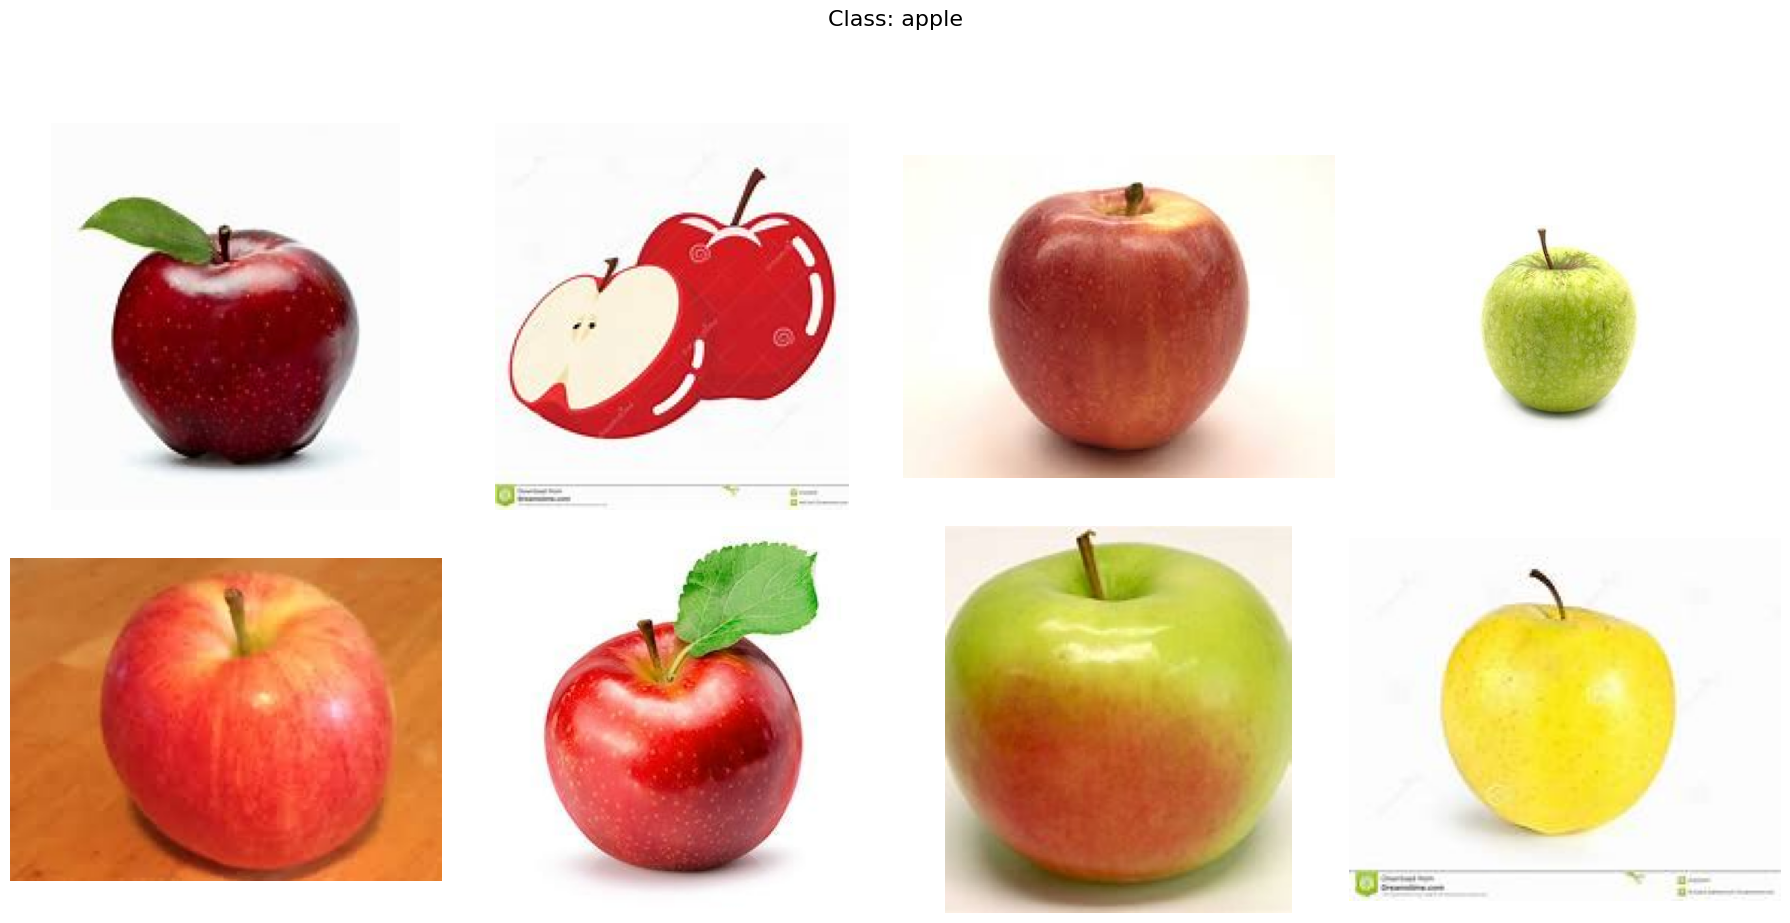

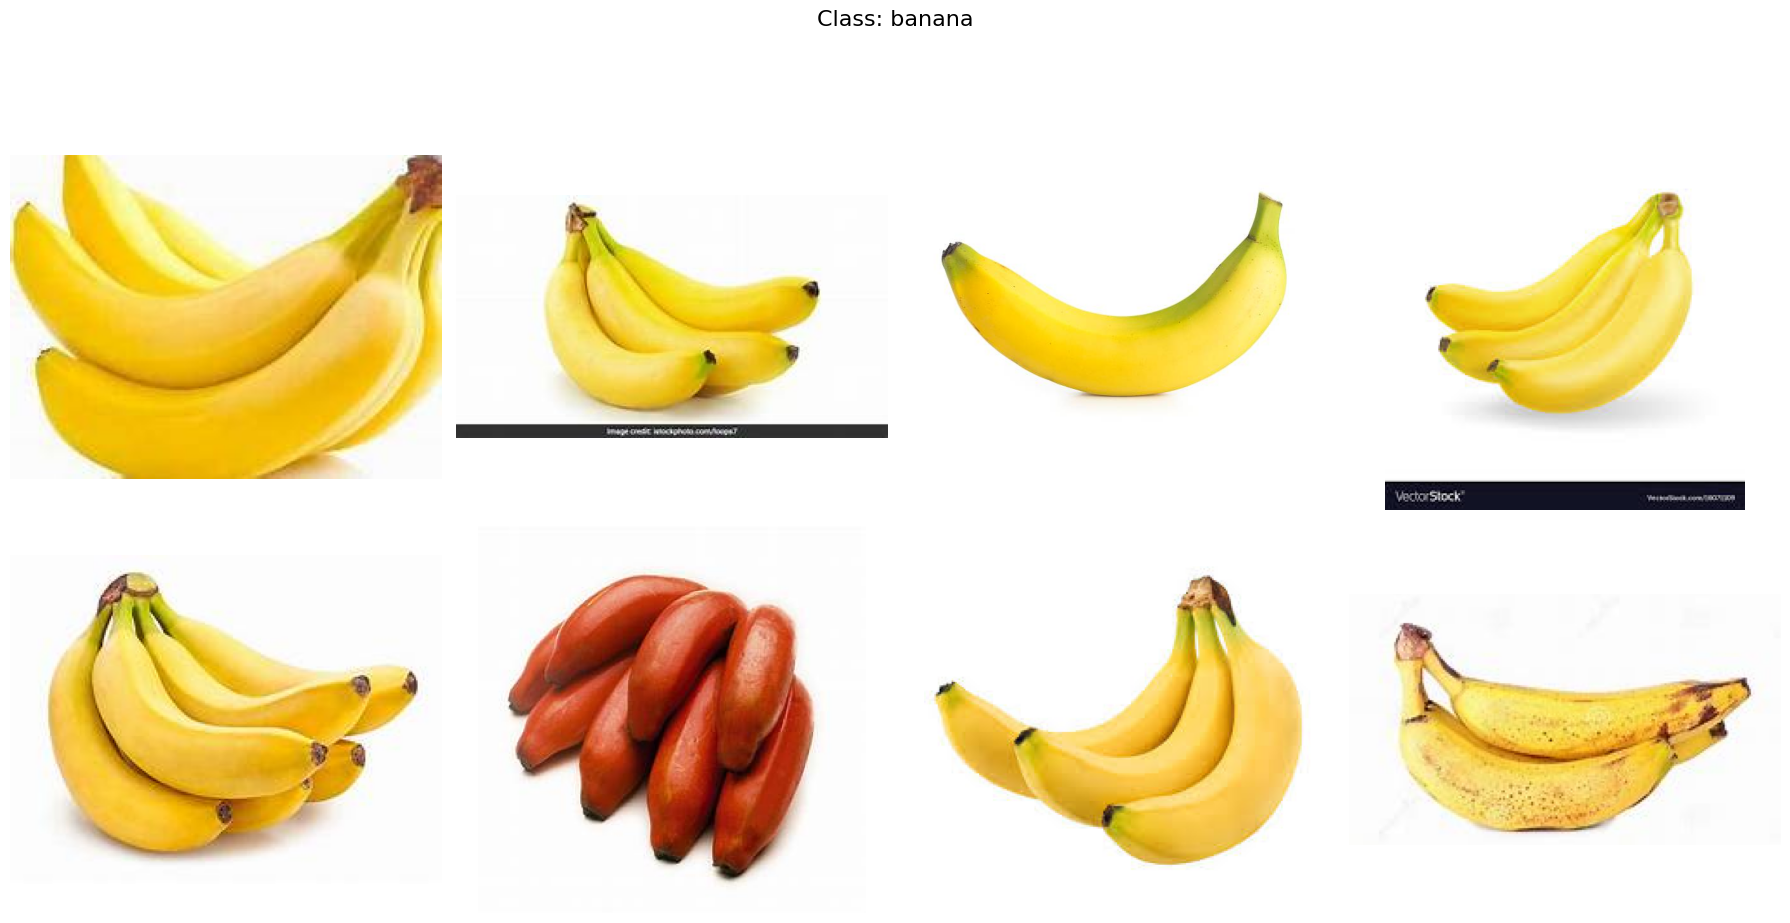

In [61]:
plot_classwise_samples(data_dir, class_names, samples_per_class_per_row=4, num_rows=2)

In [62]:
# Set your split sizes
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print(f"Total: {total_size} | Train: {train_size} | Val: {val_size} | Test: {test_size}")

# Random split (makes splits reproducible with generator seed)
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# For val/test: Override the transform to use validation transforms (NO augmentation)
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Total: 320 | Train: 224 | Val: 48 | Test: 48
Train: 224, Val: 48, Test: 48


In [63]:
train_dist = get_class_distribution(train_dataset, class_names)
val_dist = get_class_distribution(val_dataset, class_names)
test_dist = get_class_distribution(test_dataset, class_names)
print("Train class distribution:", train_dist)
print("Val class distribution:", val_dist)
print("Test class distribution:", test_dist)

Train class distribution: {'apple': 112, 'banana': 112}
Val class distribution: {'apple': 27, 'banana': 21}
Test class distribution: {'banana': 27, 'apple': 21}


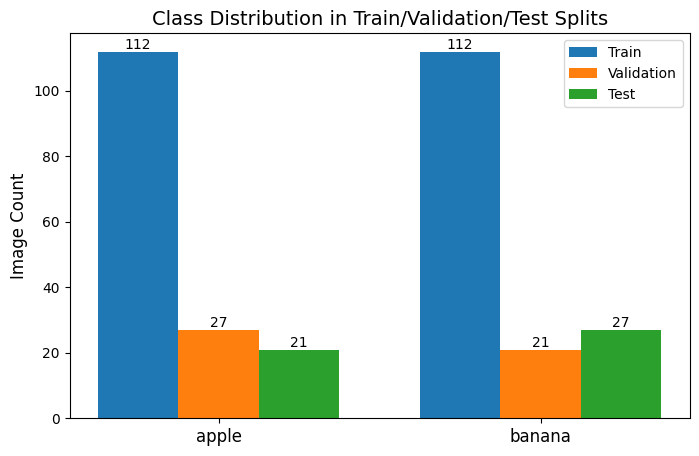

In [64]:
splits = ['Train', 'Validation', 'Test']
counts_per_class = [
    [train_dist.get(cls, 0), val_dist.get(cls, 0), test_dist.get(cls, 0)]
    for cls in class_names
]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.25
x = np.arange(len(class_names))

for i, split in enumerate(splits):
    bars = ax.bar(x + i*bar_width, [counts[i] for counts in counts_per_class], bar_width, label=split)
    # Add numbers on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')

ax.set_xticks(x + bar_width)
ax.set_xticklabels(class_names, fontsize=12)
ax.set_ylabel('Image Count', fontsize=12)
ax.set_title('Class Distribution in Train/Validation/Test Splits', fontsize=14)
ax.legend()
plt.show()

DataLoaders created.


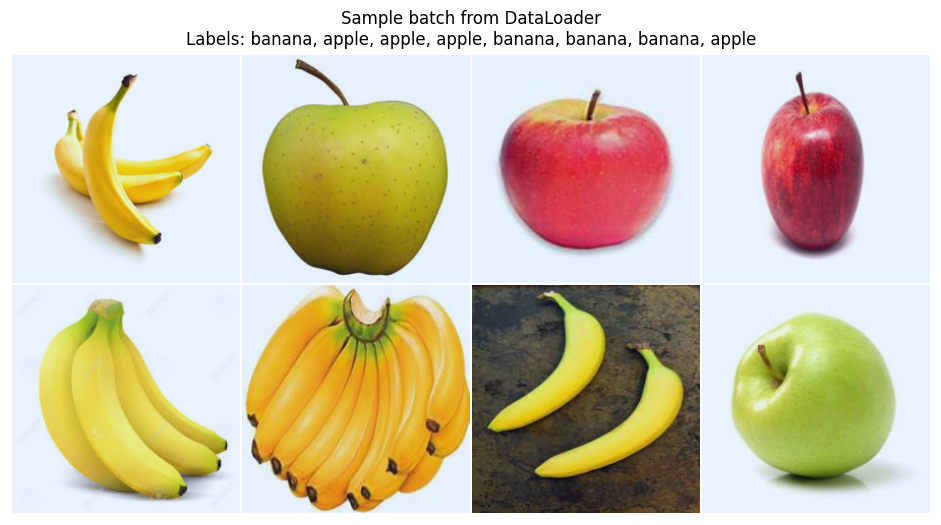

In [65]:
# Set your batch size
batch_size = 32

# DataLoaders for each split
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,      # Shuffle for training!
    num_workers=2,     # Increase if you have more CPU cores
    pin_memory=True    # Speeds up transfer to CUDA, harmless on CPU
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,     # Don't shuffle validation/test
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

# Show a batch from training data
show_batch(train_loader, class_names)


---
## 5. Model Selection & Fine-Tuning

Use a pre-trained model such as ResNet18, MobileNetV2, or EfficientNet from `torchvision.models`.

### 📌 Here's a guide snippet for loading and modifying a pre-trained model:
```python
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # Freeze all layers initially

# Replace the final layer to match the number of classes
model.fc = nn.Linear(model.fc.in_features, 2)  # for 2 classes
```

- Split your dataset into train/val (e.g., 80/20 split).
- Use an optimizer like `Adam` or `SGD`.
- Use `CrossEntropyLoss`.
- Fine-tune only the last layer at first, then optionally unfreeze more layers.

In [66]:
# Load pre-trained ResNet18
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # pretrained=True

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(class_names))  # len(class_names) = 2

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)
device

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

device(type='cuda')

In [67]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# For tracking best validation accuracy and saving weights
best_val_acc = 0
best_model_wts = None

num_epochs = 10  # or any number you wish
train_losses, val_losses, val_accs = [], [], []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_acc = correct / total
    val_losses.append(val_epoch_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Track and save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = model.state_dict().copy()

Epoch 1/10 | Train Loss: 0.7186 | Val Loss: 0.6380 | Val Acc: 0.6875
Epoch 2/10 | Train Loss: 0.4256 | Val Loss: 0.3091 | Val Acc: 0.9583
Epoch 3/10 | Train Loss: 0.2808 | Val Loss: 0.1807 | Val Acc: 0.9792
Epoch 4/10 | Train Loss: 0.1823 | Val Loss: 0.1237 | Val Acc: 1.0000
Epoch 5/10 | Train Loss: 0.1568 | Val Loss: 0.0954 | Val Acc: 0.9792
Epoch 6/10 | Train Loss: 0.1077 | Val Loss: 0.0752 | Val Acc: 1.0000
Epoch 7/10 | Train Loss: 0.0965 | Val Loss: 0.0616 | Val Acc: 1.0000
Epoch 8/10 | Train Loss: 0.0692 | Val Loss: 0.0515 | Val Acc: 1.0000
Epoch 9/10 | Train Loss: 0.0771 | Val Loss: 0.0469 | Val Acc: 1.0000
Epoch 10/10 | Train Loss: 0.0546 | Val Loss: 0.0402 | Val Acc: 1.0000


In [68]:
# After training: Load the best weights
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print(f"Loaded best model weights (Val Acc: {best_val_acc:.4f})")

torch.save(model.state_dict(), "best_model.pth")

Loaded best model weights (Val Acc: 1.0000)


---
## 6. Evaluation

- Use accuracy, confusion matrix, and classification report (from `sklearn.metrics`).
- Plot sample predictions and their ground truth.

### 🧠 **Question**:
> What do you observe about misclassifications? Are there common patterns?

### ***_Jonathan's Answer:_***  
> Most misclassifications occur when the apple images look visually different from the majority of samples from the training set, such as being very pale, yellowish, or oddly shaped.
>
> (Shown in the Visulisation Section)

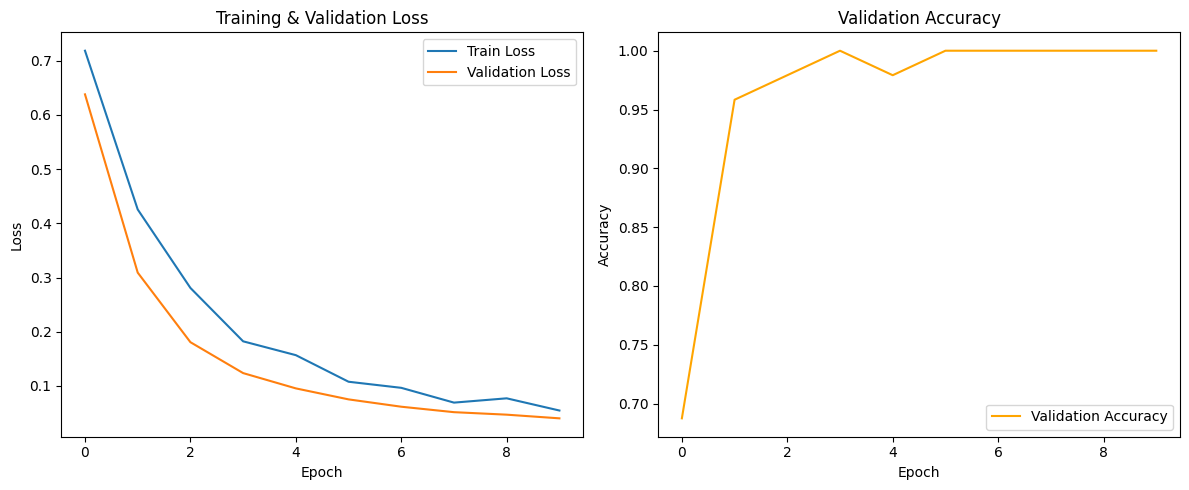

In [69]:
# Plot Loss Curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Plot Accuracy Curve
plt.subplot(1,2,2)
plt.plot(val_accs, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [70]:
# --- Collect results in a single pass ---
model.eval()
all_preds, all_labels, all_probs, all_imgs = [], [], [], []

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

test_correct, test_total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_imgs.extend(images.cpu())  # Save raw tensors for later

misclassified_count = sum(p != l for p, l in zip(all_preds, all_labels))
test_acc = test_correct / test_total
# print(f"Number of misclassified images: {misclassified_count} out of {len(all_labels)}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9583


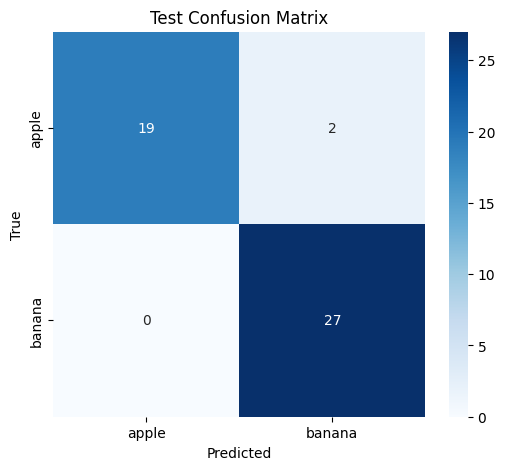

              precision    recall  f1-score   support

       apple       1.00      0.90      0.95        21
      banana       0.93      1.00      0.96        27

    accuracy                           0.96        48
   macro avg       0.97      0.95      0.96        48
weighted avg       0.96      0.96      0.96        48



In [71]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

---
## 7. Visualization

- Display sample predictions with matplotlib (or any other visualization tool).
- Show:
  - Correctly predicted images
  - Misclassified images

👉 You may want to visualize the model's confidence using softmax outputs.


In [72]:
# show_test_predictions_grid( # Show All
#     all_imgs, all_preds, all_labels, all_probs, class_names, num_cols=6, num_rows=5, misclassified_only=None
# )
num_col_correct, num_row_correct = cal_col_rows(len(all_labels) - misclassified_count, 6)
num_col_misclassified, num_row_misclassified = cal_col_rows(misclassified_count, 6)

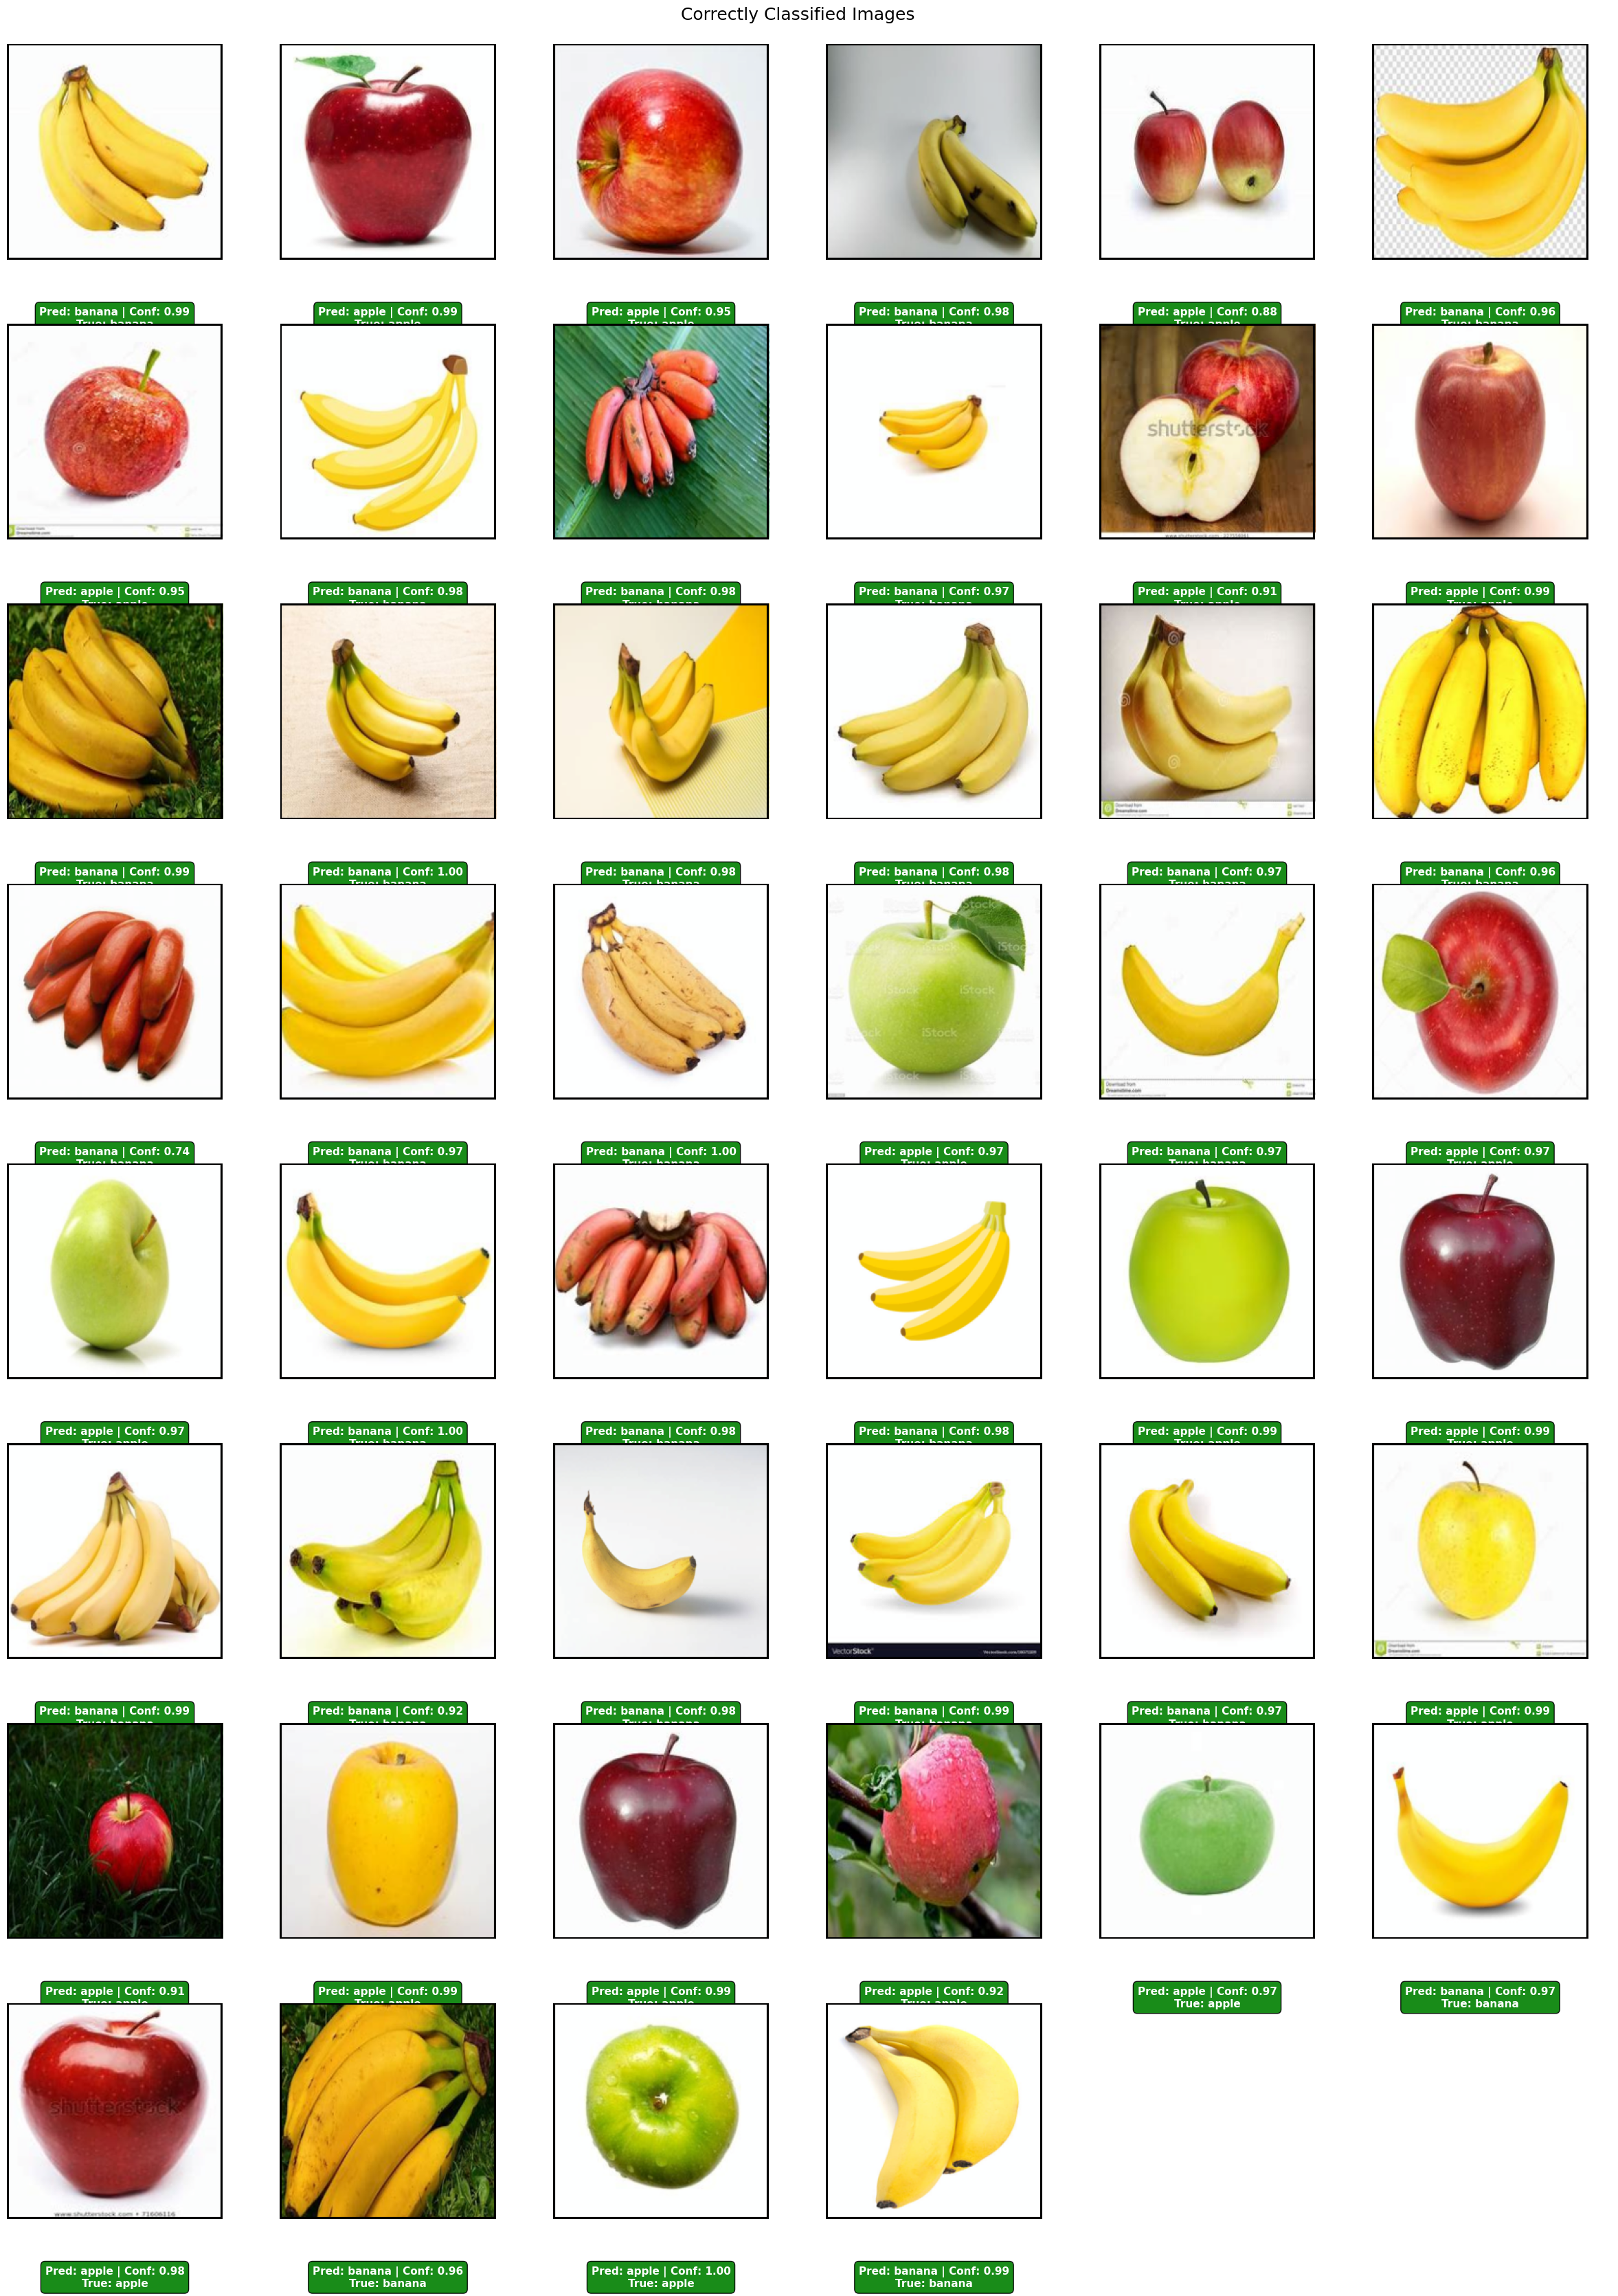

In [73]:
show_test_predictions_grid( # Show Correct Predictions
    all_imgs, all_preds, all_labels, all_probs, class_names, num_cols=num_col_correct, num_rows=num_row_correct, misclassified_only=False
)

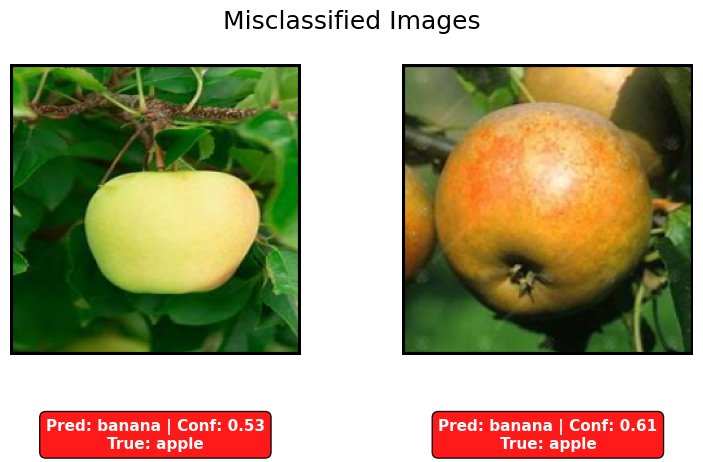

In [74]:
show_test_predictions_grid( # Show Misclassified Predictions
    all_imgs, all_preds, all_labels, all_probs, class_names, num_cols=num_col_misclassified, num_rows=num_row_misclassified, misclassified_only=True
)

---
### Submission
Submit a link to your completed Jupyter Notebook hosted on your Google Colab with all the cells executed, and answers to the assessment questions.

**NOTE: Ensure that your link is properly shared. If I cannot open your link, your project will be graded 0!**

---